In [1]:
# it is useful when you want specifly for to maintain the varience and data distribution
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("train2.csv",usecols=["Age","Fare","Survived"])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
x = df.drop(columns=["Survived"])
y = df["Survived"]

In [6]:
x

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [7]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [10]:
X_train["Age_imputed"] = X_train["Age"]
X_test["Age_imputed"] = X_test["Age"]

In [11]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_7071/3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_7071/3090101260.

In [12]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([21. , 39. , 33. , 40. , 25. , 19. , 29. , 38. , 19. , 20. , 31. ,
       16. , 56. , 43. , 24. , 36. ,  4. ,  2. ,  3. , 18. , 32. , 27. ,
       27. , 25. , 41. , 34. , 26. , 41. , 17. , 29. , 35. , 57. , 21. ,
       31. ,  9. , 18. , 37. , 28. , 39. , 18. , 21. , 26. , 48. , 56. ,
       23. ,  4. , 40. , 36. , 34.5, 30. , 22. , 30. , 35. , 42. , 28. ,
       35. , 22. , 25. , 59. ,  8. , 18. , 52. , 34. , 19. , 50. , 35. ,
        8. , 41. , 62. , 30. , 24. , 27. , 59. , 24. , 45. , 33. , 54. ,
       46. , 27. , 45. , 51. , 16. , 40. , 24. , 32. , 29. , 50. ,  5. ,
       36. , 58. , 37. , 13. , 21. , 21. , 26. , 18. , 16. , 31. , 47. ,
       27. , 35. , 18. , 32. ,  5. , 61. , 48. , 32. , 47. , 52. , 28. ,
       30.5, 20. , 21. , 54. , 16. , 21. , 44. , 63. , 29. ,  2. , 42. ,
       23. , 30. , 13. , 34. , 18. , 31. , 20. , 15. , 31. , 37. ,  2. ,
       54. , 10. , 28.5, 50. , 28.5,  9. , 21. , 31. , 27. , 24. , 26. ,
       26. , 28. , 19. , 24. , 22. ])

In [13]:
X_train["Age"].isnull().sum()

np.int64(148)

In [15]:
X_train.tail(10)

,Age,Fare,Age_imputed
263,40.0,0.0000,40.0
360,40.0,27.9000,40.0
75,25.0,7.6500,25.0
466,NaN,0.0000,62.0
299,50.0,247.5208,50.0
534,30.0,8.6625,30.0
584,NaN,8.7125,40.5
493,71.0,49.5042,71.0
527,NaN,221.7792,21.0
168,NaN,25.9250,39.0


/tmp/ipykernel_7071/4233571963.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age"],label="Original",hist=False)
/tmp/ipykernel_7071/4233571963.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train["Age_imputed"],label="Imputed",hist=False)


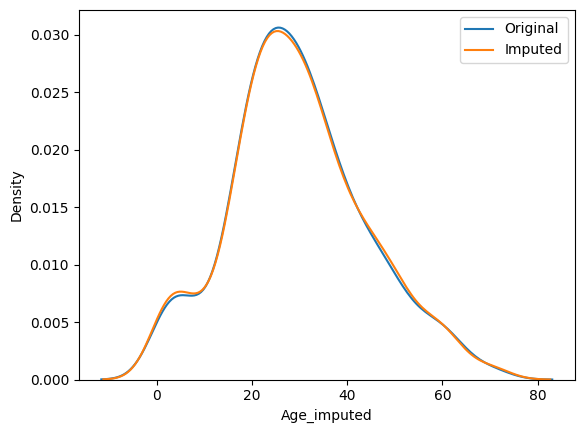

In [20]:
sns.distplot(X_train["Age"],label="Original",hist=False)
sns.distplot(X_train["Age_imputed"],label="Imputed",hist=False)

plt.legend()
plt.show()

In [21]:
print("Original Variable Varience ",X_train["Age"].var())
print("Imputed Variable Varience ",X_train["Age_imputed"].var())

Original Variable Varience  204.3495133904614
Imputed Variable Varience  208.88815723838053


In [25]:
X_train[["Age","Fare","Age_imputed"]].cov()

,Age,Fare,Age_imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,57.885858
Age_imputed,204.349513,57.885858,208.888157


<Axes: >

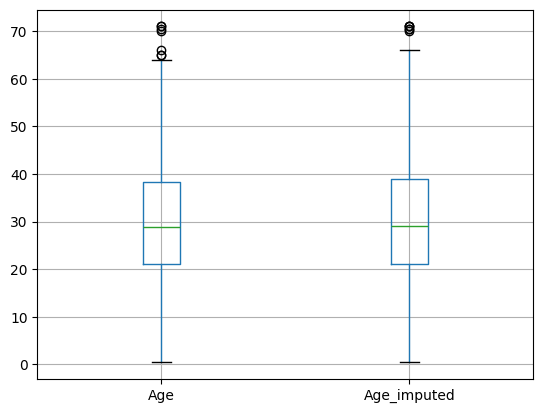

In [27]:
X_train[["Age","Age_imputed"]].boxplot()

In [29]:
data = pd.read_csv("house-train.csv",usecols=["FireplaceQu","GarageQual","SalePrice"])

In [31]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [32]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [33]:
x = data
y = data["SalePrice"]

In [34]:
x

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [35]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [36]:
X_train["GarageQual_imputed"] = X_train["GarageQual"]
X_test["GarageQual_imputed"] = X_test["GarageQual"]

X_train["FireplaceQu_imputed"] = X_train["FireplaceQu"]
X_test["FireplaceQu_imputed"] = X_test["FireplaceQu"]

In [37]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
739,NaN,TA,190000,TA,NaN
1076,TA,TA,170000,TA,TA
1140,NaN,TA,139000,TA,NaN
1082,Gd,TA,192000,TA,Gd
43,NaN,TA,130250,TA,NaN


In [38]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_7071/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp

In [40]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
618,Gd,TA,314813,TA,Gd
870,NaN,TA,109500,TA,TA
92,NaN,TA,163500,TA,Gd
817,Gd,TA,271000,TA,Gd
302,TA,TA,205000,TA,TA
...,...,...,...,...,...
763,Gd,TA,337000,TA,Gd
835,NaN,TA,128000,TA,Fa
1216,NaN,TA,112000,TA,Gd
559,TA,TA,234000,TA,TA


In [44]:
temp = pd.concat([

    X_train["GarageQual"].value_counts()/ len(X_train["GarageQual"].dropna()),
    X_train["GarageQual"].value_counts()/ len(X_train["GarageQual"])
],
                 axis=1
    
)

temp.columns = ["Original","Imputed"]

In [45]:
temp

,Original,Imputed
GarageQual,,
TA,0.950450,0.903253
Fa,0.036036,0.034247
Gd,0.009009,0.008562
Po,0.002703,0.002568
Ex,0.001802,0.001712


In [48]:
temp2 = pd.concat([

    X_train["FireplaceQu"].value_counts() / len(X_train["FireplaceQu"].dropna()),
    X_train["FireplaceQu"].value_counts() / len(X_train["FireplaceQu"])
    
],axis=1)

temp2.columns = ["Original","Imputed"]

In [49]:
temp2

,Original,Imputed
FireplaceQu,,
Gd,0.478120,0.252568
TA,0.416532,0.220034
Fa,0.047002,0.024829
Ex,0.030794,0.016267
Po,0.027553,0.014555


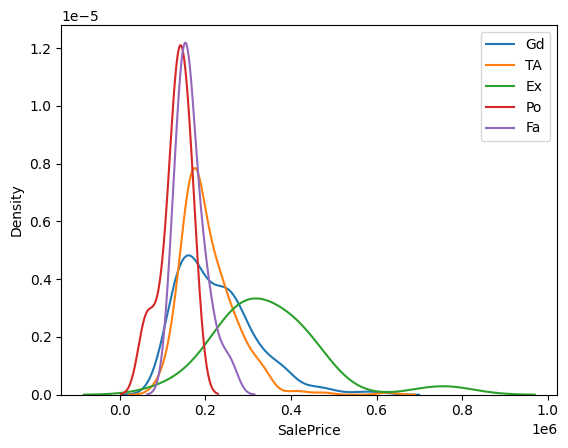

In [58]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)

plt.legend()
plt.show()

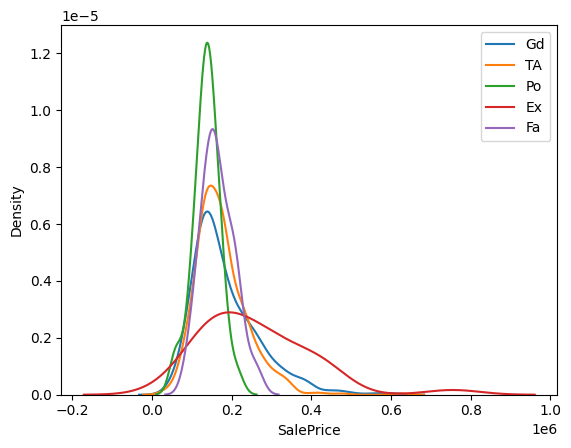

In [59]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)

plt.legend()
plt.show()